# Scene Classification Feature Preprocessing

This notebook prepares the labelled scene images for the later models. It creates one common image representation, builds several hand-crafted features and prepares controlled image changes for the robustness study.

In [1]:
import numpy as np
import gc
import os
import pickle
from PIL import Image
from scipy.ndimage import gaussian_filter
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray

np.random.seed(42)

## Experiment settings

This section sets the dataset locations, the scene classes, the common image size and the severity levels for the robustness experiment. These choices define one consistent setup for the rest of the notebook.

In [ ]:
# The dataset is stored in img_data/seg_train and img_data/seg_test.
BASE_DIR   = 'img_data'
TRAIN_DIR  = os.path.join(BASE_DIR, 'seg_train')
TEST_DIR   = os.path.join(BASE_DIR, 'seg_test')
FEAT_DIR   = 'features'
os.makedirs(FEAT_DIR, exist_ok=True)

CLASSES      = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IMG_SIZE     = (150, 150)
BATCH_SIZE   = 128

# Corruption levels: clean, mild, medium, and severe.
SEVERITY_NAMES     = ['clean', 'mild', 'medium', 'severe']
BLUR_SIGMAS        = [0, 1, 2, 3]
BRIGHTNESS_FACTORS = [1.0, 0.8, 0.6, 0.4]

## Image preparation

We create one consistent image format for the whole dataset. The process keeps labelled images with a reasonable original size, converts them to RGB, resizes them to 150x150 and scales the pixel values to the range [0, 1]. The resulting labelled data supports the later cross-validation experiments.

In [ ]:
# Build one labelled image array for a dataset split.
def load_images(base_dir):
    # Load labelled images and apply RGB conversion, resizing, and scaling.
    images, labels = [], []
    for cls in CLASSES:
        cls_dir = os.path.join(base_dir, cls)
        for fname in sorted(os.listdir(cls_dir)):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
            # Exclude images whose original width or height is below 100 pixels.
            if img.width < 100 or img.height < 100:
                print(f'Skipping undersized image: {cls}/{fname}, size={img.size}')
                continue
            img = img.resize(IMG_SIZE, Image.BILINEAR)
            images.append(np.array(img, dtype=np.float32) / 255.0)
            labels.append(CLASS_TO_IDX[cls])
    return images, labels

print('Loading all images...')
all_images, all_labels = [], []
for base_dir in [TRAIN_DIR, TEST_DIR]:
    imgs, lbls = load_images(base_dir)
    all_images.extend(imgs)
    all_labels.extend(lbls)

X_all_raw = np.array(all_images)
y_all     = np.array(all_labels)

# Release temporary lists after creating the unified arrays.
del all_images, all_labels
gc.collect()

print(f'  Total: {X_all_raw.shape}, labels: {y_all.shape}')
print(f'  Valid image count after filtering: {X_all_raw.shape[0]}')
print(f'  Resized image shape: {X_all_raw.shape[1:]}')

Loading all images...
Skipping undersized image: glacier/2837.jpg, size=(150, 76)
Skipping undersized image: glacier/3148.jpg, size=(150, 97)
Skipping undersized image: mountain/7400.jpg, size=(150, 81)
Skipping undersized image: glacier/21657.jpg, size=(150, 76)
Skipping undersized image: glacier/23169.jpg, size=(150, 72)
Skipping undersized image: mountain/22765.jpg, size=(150, 81)
  Total: (17028, 150, 150, 3), labels: (17028,)
  Valid image count after filtering: 17028
  Resized image shape: (150, 150, 3)


## Hand-crafted visual features

We describe each image from several viewpoints. Colour histograms capture colour distribution, HOG describes edges and shape, LBP captures local texture and the spatial feature keeps coarse location information. Together, these representations give the models different types of visual information.

In [4]:
# Describe the image with RGB colour histograms.
def colour_histogram(img, n_bins=32):
    """Compute per-channel colour histograms and normalise each to sum to 1.
    Output shape: (n_bins * 3,).
    """
    feats = []
    for ch in range(3):
        hist, _ = np.histogram(img[:, :, ch], bins=n_bins, range=(0.0, 1.0))
        feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats).astype(np.float32)


# Describe edges and simple shape structure with HOG.
def hog_features(img):
    """Convert the image to grayscale and extract HOG edge and shape features.
    Output shape: (576,).
    """
    gray = rgb2gray(img)
    return hog(gray, orientations=9, pixels_per_cell=(30, 30),
               cells_per_block=(2, 2), visualize=False).astype(np.float32)


# Describe local texture patterns with LBP.
def lbp_features(img, n_points=24, radius=3):
    """Convert grayscale values to uint8 before computing a uniform LBP histogram.
    Output shape: (26,).
    """
    gray = (rgb2gray(img) * 255).astype(np.uint8)
    lbp  = local_binary_pattern(gray, n_points, radius, method='uniform')
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins))
    return (hist / (hist.sum() + 1e-8)).astype(np.float32)


# Describe average colour information in a spatial grid.
def spatial_features(img, grid=2):
    """
    Divide the image into grid x grid regions and extract colour, HOG, and LBP features.
    This preserves spatial information that global histograms discard.
    """
    H, W  = img.shape[:2]
    ch, cw = H // grid, W // grid
    feats  = []
    for i in range(grid):
        for j in range(grid):
            cell = img[i*ch:(i+1)*ch, j*cw:(j+1)*cw]
            feats.append(colour_histogram(cell, n_bins=16))   # 48-dimensional colour feature
            feats.append(hog_features(cell))                  # HOG feature for the region
            feats.append(lbp_features(cell))                  # 26-dimensional texture feature
    return np.concatenate(feats).astype(np.float32)


# Combine the four feature representations for one image.
def extract_features(img):
    return {
        'colour':  colour_histogram(img),
        'hog':     hog_features(img),
        'lbp':     lbp_features(img),
        'spatial': spatial_features(img),
    }


# Extract features for one batch of images.
def extract_batch(images, desc=''):
    result = {k: [] for k in ('colour', 'hog', 'lbp', 'spatial')}
    n = len(images)
    for i, img in enumerate(images):
        if i % 1000 == 0:
            print(f'  {desc}: {i}/{n}')
        f = extract_features(img)
        for k in result:
            result[k].append(f[k])
    return {k: np.array(v) for k, v in result.items()}


# Check the feature shapes for one sample image.
sample = extract_features(X_all_raw[0])
for k, v in sample.items():
    print(f'{k:10s}: {v.shape}')

colour    : (96,)
hog       : (576,)
lbp       : (26,)
spatial   : (440,)


## Controlled image changes

We create two controlled changes for the robustness study. Gaussian blur represents a loss of image sharpness, while brightness change represents a change in lighting. Each type has a clean version and three increasing levels: mild, medium and severe. Every version keeps the same image order and labels, which lets the later models make a fair condition-by-condition comparison.

In [5]:
# Create a blur version with the chosen severity.
def apply_blur(img, sigma):
    # Apply Gaussian smoothing independently to each RGB channel.
    if sigma == 0:
        return img.copy()
    out = np.stack(
        [gaussian_filter(img[:, :, c], sigma=sigma) for c in range(3)],
        axis=-1
    )
    return np.clip(out, 0.0, 1.0).astype(np.float32)


# Create a brightness version with the chosen severity.
def apply_brightness(img, factor):
    # Adjust image brightness and keep pixel values within the valid range.
    return np.clip(img * factor, 0.0, 1.0).astype(np.float32)

## Corruption visualisation

We use one fixed source image to show the clean version, the three blur levels and the three brightness levels. This figure helps the report show what each severity level looks like before the numerical robustness results.

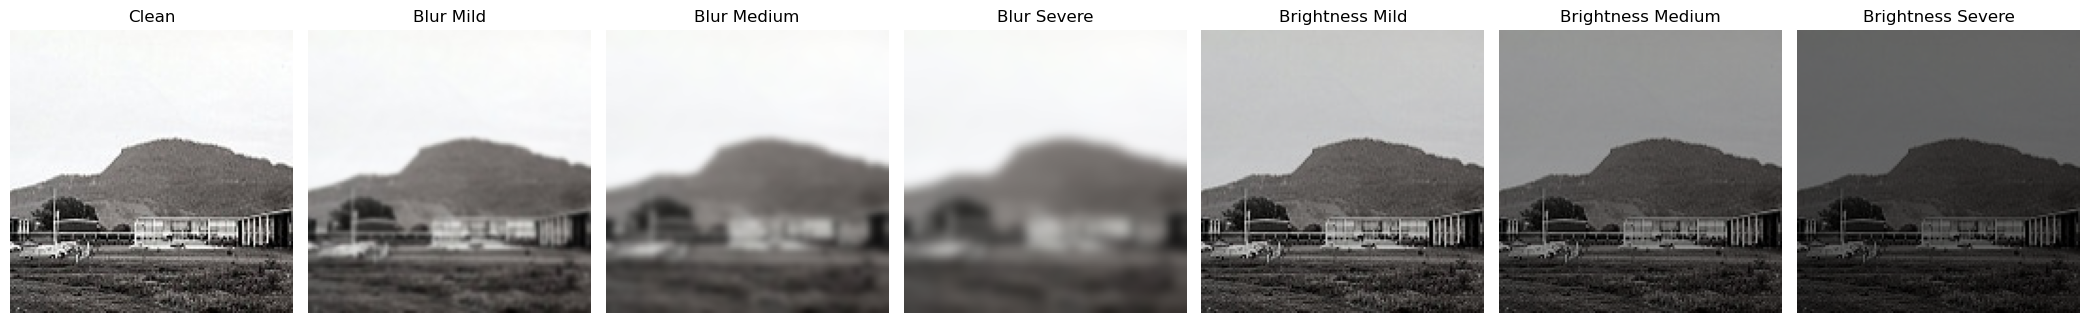

Corruption visualization saved to: features/corruption_visualization.png


In [6]:
import matplotlib.pyplot as plt

# Use one fixed source image for all visualization panels.
example_index = 0
example_image = X_all_raw[example_index]

visualization_versions = [
    ('Clean', example_image),
    ('Blur Mild', apply_blur(example_image, BLUR_SIGMAS[1])),
    ('Blur Medium', apply_blur(example_image, BLUR_SIGMAS[2])),
    ('Blur Severe', apply_blur(example_image, BLUR_SIGMAS[3])),
    ('Brightness Mild', apply_brightness(example_image, BRIGHTNESS_FACTORS[1])),
    ('Brightness Medium', apply_brightness(example_image, BRIGHTNESS_FACTORS[2])),
    ('Brightness Severe', apply_brightness(example_image, BRIGHTNESS_FACTORS[3])),
]

fig, axes = plt.subplots(1, 7, figsize=(21, 3.5))
for ax, (title, image) in zip(axes, visualization_versions):
    ax.imshow(image, vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.axis('off')

fig.tight_layout()
visualization_path = os.path.join(FEAT_DIR, 'corruption_visualization.png')
fig.savefig(visualization_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Corruption visualization saved to: {visualization_path}')

## Feature extraction and saved data

This stage turns every image condition into the four feature representations. We process the data in batches, keep the matching indices and labels, and save the feature files for the Logistic Regression and MLP notebooks.

In [7]:
# Extract features for one condition in manageable batches.
def extract_condition_in_batches(images, transform, desc='', batch_size=128):
    """Generate corrupted images by batch and extract features immediately.
    This avoids storing the complete corrupted image array in memory.
    """
    feature_parts = {k: [] for k in ('colour', 'hog', 'lbp', 'spatial')}
    n = len(images)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        # Temporarily store corrupted images only for the current batch.
        transformed_batch = np.stack([transform(img) for img in images[start:end]], axis=0)
        batch_features = extract_batch(transformed_batch, f'{desc} {start}:{end}')
        for key in feature_parts:
            feature_parts[key].append(batch_features[key])
        del transformed_batch, batch_features

    return {key: np.concatenate(parts, axis=0) for key, parts in feature_parts.items()}


# Save one condition with its features, labels and indices.
def save_condition_features(condition_name, transform, batch_size=BATCH_SIZE):
    """Extract and save one condition, including the original indices and labels."""
    print(f'Processing condition: {condition_name}')
    condition_features = extract_condition_in_batches(
        X_all_raw, transform, desc=condition_name, batch_size=batch_size
    )
    output_path = os.path.join(FEAT_DIR, f'{condition_name}.npz')
    np.savez(
        output_path,
        indices=np.arange(len(y_all)),
        labels=y_all,
        **condition_features
    )
    print(f'Saved: {output_path}')
    del condition_features
    gc.collect()


# Save clean level 0 once and reuse it for both corruption experiments.
condition_files = {
    'blur_0': 'clean.npz',
    'brightness_0': 'clean.npz',
}
save_condition_features('clean', lambda img: img, batch_size=BATCH_SIZE)

# Save the mild, medium, and severe Gaussian blur conditions.
for severity, sigma in zip(SEVERITY_NAMES[1:], BLUR_SIGMAS[1:]):
    condition_name = f'blur_{severity}'
    condition_files[condition_name] = f'{condition_name}.npz'
    save_condition_features(
        condition_name,
        lambda img, current_sigma=sigma: apply_blur(img, current_sigma),
        batch_size=BATCH_SIZE
    )

# Save the mild, medium, and severe brightness change conditions.
for severity, factor in zip(SEVERITY_NAMES[1:], BRIGHTNESS_FACTORS[1:]):
    condition_name = f'brightness_{severity}'
    condition_files[condition_name] = f'{condition_name}.npz'
    save_condition_features(
        condition_name,
        lambda img, current_factor=factor: apply_brightness(img, current_factor),
        batch_size=BATCH_SIZE
    )

with open(os.path.join(FEAT_DIR, 'condition_manifest.pkl'), 'wb') as f:
    pickle.dump({
        'conditions': condition_files,
        'severity_names': SEVERITY_NAMES,
        'labels': y_all,
    }, f)
print('All condition features have been saved separately.')

Processing condition: clean
  clean 0:128: 0/128
  clean 128:256: 0/128
  clean 256:384: 0/128
  clean 384:512: 0/128
  clean 512:640: 0/128
  clean 640:768: 0/128
  clean 768:896: 0/128
  clean 896:1024: 0/128
  clean 1024:1152: 0/128
  clean 1152:1280: 0/128
  clean 1280:1408: 0/128
  clean 1408:1536: 0/128
  clean 1536:1664: 0/128
  clean 1664:1792: 0/128
  clean 1792:1920: 0/128
  clean 1920:2048: 0/128
  clean 2048:2176: 0/128
  clean 2176:2304: 0/128
  clean 2304:2432: 0/128
  clean 2432:2560: 0/128
  clean 2560:2688: 0/128
  clean 2688:2816: 0/128
  clean 2816:2944: 0/128
  clean 2944:3072: 0/128
  clean 3072:3200: 0/128
  clean 3200:3328: 0/128
  clean 3328:3456: 0/128
  clean 3456:3584: 0/128
  clean 3584:3712: 0/128
  clean 3712:3840: 0/128
  clean 3840:3968: 0/128
  clean 3968:4096: 0/128
  clean 4096:4224: 0/128
  clean 4224:4352: 0/128
  clean 4352:4480: 0/128
  clean 4480:4608: 0/128
  clean 4608:4736: 0/128
  clean 4736:4864: 0/128
  clean 4864:4992: 0/128
  clean 4992:5